<a href="https://colab.research.google.com/github/akshay-aiml/LangChain_LangGraph/blob/main/Parallel_workflow_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain-groq langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.2 MB/s eta 0:00:00


In [3]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [5]:
from google.colab import userdata

api_key = userdata.get("GROQ_API_KEY")

In [6]:
llm = ChatGroq(model="llama-3.1-8b-instant",
               api_key=api_key,
               temperature=0.2)

In [31]:
from pydantic import BaseModel, Field, field_validator, model_validator
import re
from typing import Optional

# Define the output structure for each evaluation using Pydantic
class EvaluationSchema(BaseModel):
    feedback: str = Field(description='Detailed feedback for the essay')
    score: Optional[int] = Field(None, description='Score out of 10', ge=0, le=10)

    @field_validator('score', mode='after')
    @classmethod
    def extract_score_from_feedback_if_missing(cls, v: Optional[int], info):
        if v is None and 'feedback' in info.data:
            feedback_text = info.data['feedback']
            match = re.search(r'Score:\s*(\d+)/10', feedback_text)
            if match:
                extracted_score = int(match.group(1))
                return extracted_score
        if v is None:
            # If score is still None, provide a default or raise an error if appropriate
            # For now, we'll return None and let the model_validator handle cleanup if needed
            pass # Or raise ValueError("Score could not be determined from feedback.")
        return v

    @model_validator(mode='after')
    def clean_feedback_after_validation(self):
        if self.score is not None:
            # Remove "Score: X/10" from feedback if score was extracted or provided separately
            self.feedback = re.sub(r'Score:\s*\d+/10', '', self.feedback).strip()
        return self

In [32]:
# Wrap the model with structured output for schema-based responses
structured_model = llm.with_structured_output(EvaluationSchema)

In [33]:
# Define the full state that flows through the graph
class EssayState(TypedDict):
    input_topic : str        # topic
    essay: str              # essay text
    language_feedback: str  # feedback on grammar and clarity
    analysis_feedback: str  # feedback on depth of argument
    clarity_feedback: str   # feedback on clarity of thought
    overall_feedback: str   # final feedback from all sections
    individual_scores: Annotated[list[int], operator.add]  # scores from 3 sections
    avg_score: float        # average of all 3 scores

In [34]:
# define nodes 1: to generate text
def generate_text(State:EssayState) -> EssayState:
  input_topic = State["input_topic"]
  prompt = f"Write a clear and informative article of approximately 400 - 450 words about the : {input_topic}"
  State["essay"] = llm.invoke(prompt).content
  return State

In [35]:
def evaluate_language(state: EssayState):
    prompt = f"Evaluate the language quality of the following essay. Provide detailed feedback for the 'feedback' field (do not include the score in this feedback text) and a numerical score out of 10 for the 'score' field. Essay:\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [36]:
def evaluate_analysis(state: EssayState):
    prompt = f"Evaluate the depth of analysis of the following essay. Provide detailed feedback for the 'feedback' field (do not include the score in this feedback text) and a numerical score out of 10 for the 'score' field. Essay:\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [37]:
def evaluate_thought(state: EssayState):
    prompt = f"Evaluate the clarity of thought of the following essay. Provide detailed feedback for the 'feedback' field (do not include the score in this feedback text) and a numerical score out of 10 for the 'score' field. Essay:\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [38]:
# Final node: Summarize all feedbacks and calculate average score
def final_evaluation(state: EssayState):
    prompt = (
        f'Based on the following feedbacks create a summarized feedback:\n'
        f'Language: {state["language_feedback"]}\n'
        f'Depth of Analysis: {state["analysis_feedback"]}\n'
        f'Clarity of Thought: {state["clarity_feedback"]}'
    )
    overall_feedback = llm.invoke(prompt).content
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])
    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [39]:
# Create the graph structure using LangGraph
graph = StateGraph(EssayState)

# Add individual evaluation nodes
graph.add_node('generate_text', generate_text)
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# to add node
graph.add_edge(START, "generate_text")

#  node connects to all 3 evaluators in parallel
graph.add_edge("generate_text", 'evaluate_language')
graph.add_edge('generate_text', 'evaluate_analysis')
graph.add_edge('generate_text', 'evaluate_thought')

# Each evaluator connects to the final evaluation node
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

# Final evaluation node connects to END
graph.add_edge('final_evaluation', END)

In [40]:
# Compile the graph into a runnable workflow
workflow = graph.compile()

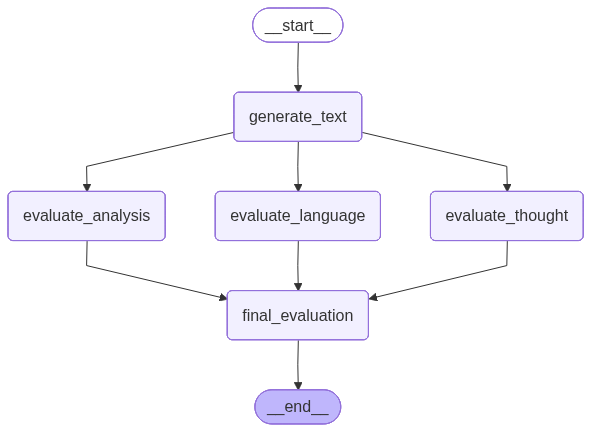

In [41]:
# Draw the Graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [42]:
input_topic = {"input_topic" : "Agriculture in India"}

output = workflow.invoke(input_topic)

In [43]:
print(output["essay"])

**Agriculture in India: A Vital Sector Driving the Country's Economy**

Agriculture is the backbone of India's economy, accounting for approximately 18% of the country's GDP and employing over 50% of the workforce. The sector has been a vital component of India's economy for centuries, providing food, employment, and income to millions of people. In this article, we will delve into the importance of agriculture in India, its current state, and the challenges it faces.

**History and Significance**

Agriculture in India dates back to the Indus Valley Civilization, where people cultivated crops such as wheat, barley, and rice. Over time, the sector has evolved, and India has become one of the world's largest producers of agricultural products, including rice, wheat, cotton, and sugarcane. Agriculture is not only a source of food but also a major contributor to India's exports, with the country being one of the largest exporters of agricultural products in the world.

**Current State**

I

In [52]:
# generate score
print("Language Feedback:", output['language_feedback'], "\n")
print("Analysis Feedback:", output['analysis_feedback'], "\n")
print("Clarity Feedback:", output['clarity_feedback'], "\n")
print("Individual Scores:", output['individual_scores'])

Language Feedback: The essay provides a comprehensive overview of the importance of agriculture in India, its current state, and the challenges it faces. The language is clear and concise, and the structure is well-organized. The use of subheadings and bullet points makes the essay easy to follow. The writer has done a good job of providing specific examples and statistics to support their arguments. However, the essay could benefit from more nuanced analysis and critical thinking. The writer relies heavily on general statements and could delve deeper into the complexities of the issue. Additionally, the essay could benefit from more varied sentence structures and vocabulary to keep the reader engaged. Overall, the essay is well-written and provides a solid foundation for further discussion. 

Analysis Feedback: The essay provides a comprehensive analysis of the importance of agriculture in India, its current state, and the challenges it faces. The writer has done a good job of delving

In [53]:
print("Overall_feedback:", output['overall_feedback'], "\n")
print("Avg_score:", output['avg_score'])

Overall_feedback: Here's a summarized feedback:

**Strengths:**

- The essay provides a comprehensive overview of the importance of agriculture in India, its current state, and the challenges it faces.
- The language is clear and concise, and the structure is well-organized.
- The use of subheadings, bullet points, and transitional phrases makes the essay easy to follow.
- The writer has done a good job of providing specific examples and statistics to support their arguments.
- The essay demonstrates a good understanding of the topic and provides a solid foundation for further discussion.

**Weaknesses:**

- The essay relies heavily on general statements and could benefit from more nuanced analysis and critical thinking.
- The writer could delve deeper into the complexities of the issue and provide more in-depth analysis of the impact of government initiatives.
- The essay could benefit from more varied sentence structures and vocabulary to keep the reader engaged.
- Some points, such 